<a href="https://colab.research.google.com/github/daveveed/Geo-Data-Science/blob/main/mapping_gridded_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
%%capture
if 'google.colab' in str(get_ipython()):
 !pip install cartopy

In [4]:
import cartopy, cartopy.crs as ccrs, os, matplotlib.pyplot as plt, xarray as xr

In [6]:
import requests

In [5]:
data_folder = 'data'
output_folder = 'output'

if not os.path.exists(data_folder):
  os.mkdir(data_folder)
if not os.path.exists(output_folder):
  os.mkdir(output_folder)

In [7]:
def download(url):
    filename = os.path.join(data_folder, os.path.basename(url))
    if not os.path.exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)

filename = 'gistemp1200_GHCNv4_ERSSTv5.nc'

data_url = 'https://github.com/spatialthoughts/python-dataviz-web/releases/' \
  'download/gistemp/'

download(data_url + filename)

Downloaded data/gistemp1200_GHCNv4_ERSSTv5.nc


## data preprocessing

In [9]:
file_path = os.path.join(data_folder, filename)
ds = xr.open_dataset(file_path)
da = ds.tempanomaly
da

<xarray.DataArray 'tempanomaly' (time: 1733, lat: 90, lon: 180)> Size: 112MB
[28074600 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 14kB 1880-01-15 1880-02-15 ... 2024-05-15
  * lat      (lat) float32 360B -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * lon      (lon) float32 720B -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
Attributes:
    long_name:     Surface temperature anomaly
    units:         K
    cell_methods:  time: mean

In [13]:
# yearly anomalies from 1880
yearly = da.groupby('time.year').mean(dim='time')
yearly

<xarray.DataArray 'tempanomaly' (year: 145, lat: 90, lon: 180)> Size: 9MB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [ 3.6616666 ,  3.6616666 ,  3.6616666 , ...,  3.6616666 ,
          3.6616666 ,  3.6616666 ],
        [ 3.6616666 ,  3.6616666 ,  3.6616666 , ...,  3.6616666 ,
          3.6616666 ,  3.6616666 ],
        [ 3.6616666 ,  3.6616666 ,  3.6616666 , ...,  3.6616666 ,
          3.6616666 ,  3.6616666 ]],

       [[-0.748     , -0.748     , -0.748     , ..., -0.748     ,
         -0.748     , -0.748     ],
        [-0.748     , -0.748     , -0.748     , ..., -0.748     ,
         -0.748     , -0.748     ],
        [-0.748     , -0.748     , -0.748     , ..., -0.748     ,
         -0.748     , -0.748     ],
        ...,
        [ 4.4999995 ,  4.4999995 ,  4.4999995 , ...,  4.4999995 ,
          4.4999995 ,  4.4999995 ],
        [ 4.4999995 ,  4.4999995 ,  4.4999995 , ...,  4.4999995 ,
          4.4999995 ,  4.4999995 ],
        [ 4.4999995 ,  4.4999995 ,  4.4999995 , ...,  4.4999995 ,
          4.4999995 ,  4.4999995 ]]], dtype=float32)
Coordinates:
  * year     (year) int64 1kB 1880 1881 1882 1883 1884 ... 2021 2022 2023 2024
  * lat      (lat) float32 360B -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * lon      (lon) float32 720B -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
Attributes:
    long_name:     Surface temperature anomaly
    units:         K
    cell_methods:  time: mean

## plotting

In [14]:
year = 2023

In [15]:
anomaly = yearly.sel(year=year)
anomaly

<xarray.DataArray 'tempanomaly' (lat: 90, lon: 180)> Size: 65kB
array([[-0.10916665, -0.10916665, -0.10916665, ..., -0.10916665,
        -0.10916665, -0.10916665],
       [-0.10916665, -0.10916665, -0.10916665, ..., -0.10916665,
        -0.10916665, -0.10916665],
       [-0.10916665, -0.10916665, -0.10916665, ..., -0.10916665,
        -0.10916665, -0.10916665],
       ...,
       [ 3.6616666 ,  3.6616666 ,  3.6616666 , ...,  3.6616666 ,
         3.6616666 ,  3.6616666 ],
       [ 3.6616666 ,  3.6616666 ,  3.6616666 , ...,  3.6616666 ,
         3.6616666 ,  3.6616666 ],
       [ 3.6616666 ,  3.6616666 ,  3.6616666 , ...,  3.6616666 ,
         3.6616666 ,  3.6616666 ]], dtype=float32)
Coordinates:
  * lat      (lat) float32 360B -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * lon      (lon) float32 720B -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
    year     int64 8B 2023
Attributes:
    long_name:     Surface temperature anomaly
    units:         K
    cell_methods:  time: mean

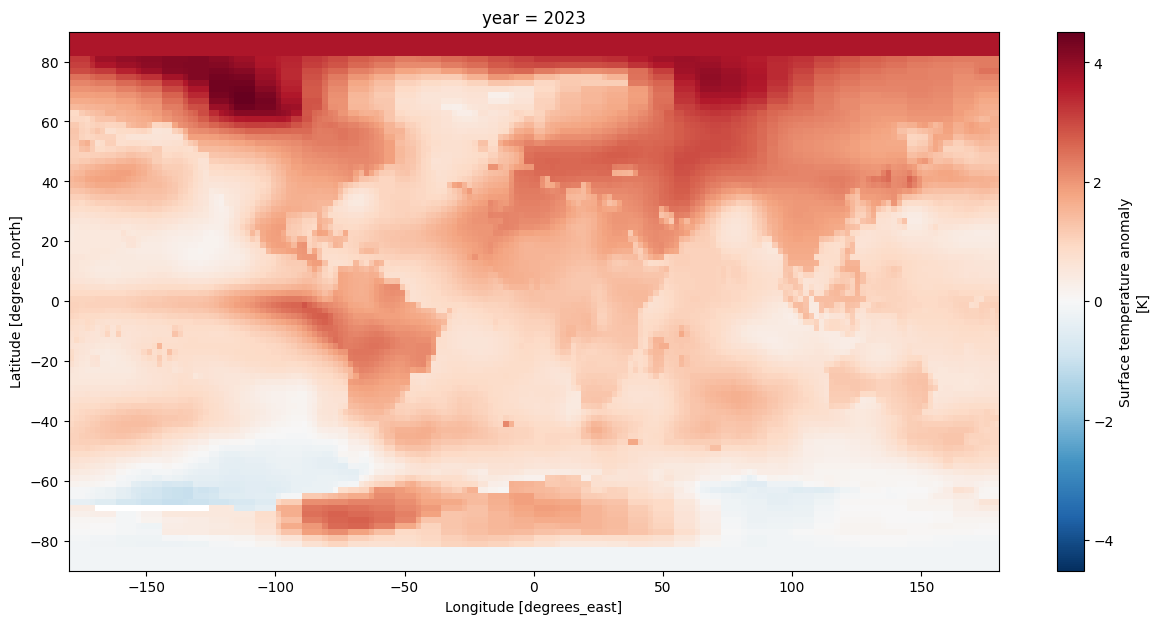

In [17]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(15,7)
anomaly.plot.imshow(ax = ax)
plt.show()

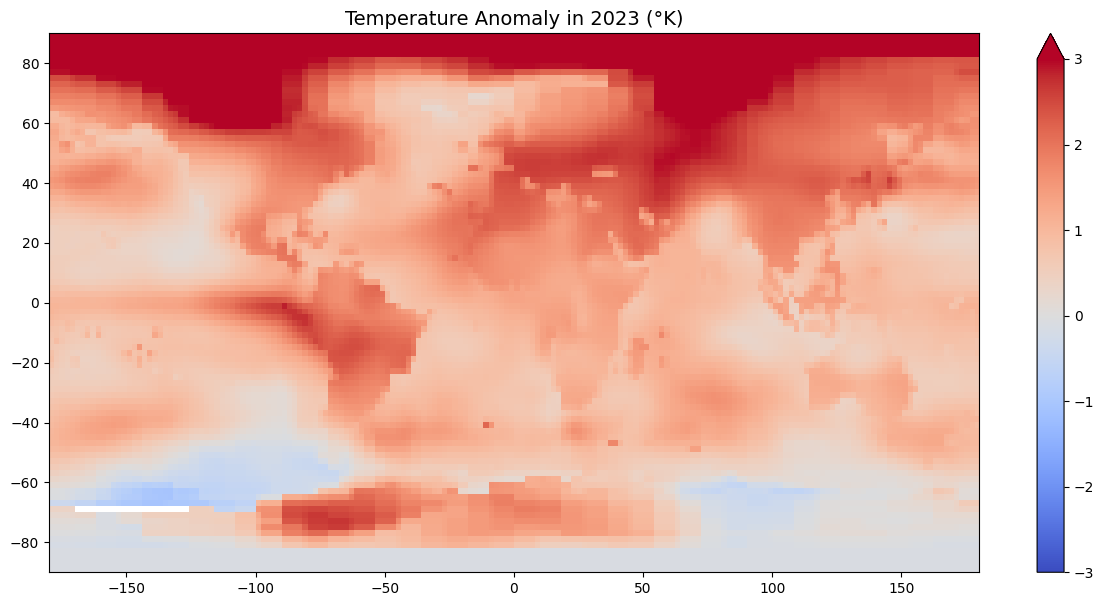

In [21]:
fig,ax = plt.subplots(1,1)
fig.set_size_inches(15,7)

anomaly.plot.imshow(ax=ax,
                    vmin=-3,
                    vmax=3, add_labels=False, cmap='coolwarm')

ax.set_title(f'Temperature Anomaly in {year} (°K)', fontsize = 14)

plt.show()

## plotting with cartopy

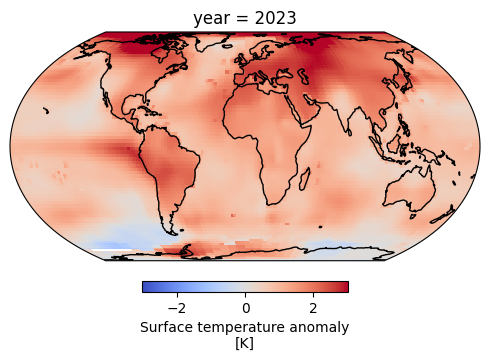

In [25]:
projection = ccrs.EqualEarth(0, 30)

fig, ax = plt.subplots(1, 1, subplot_kw={'projection': projection})
fig.set_size_inches(5,5)

cbar_kwargs = {
    'orientation':'horizontal',
    'fraction': 0.025,
    'pad': 0.05,
    'extend':'neither'
}

anomaly.plot.imshow(ax=ax,
    vmin=-3, vmax=3, cmap='coolwarm',
    transform=ccrs.PlateCarree(),
    cbar_kwargs=cbar_kwargs)

ax.coastlines()
plt.tight_layout()
plt.show()

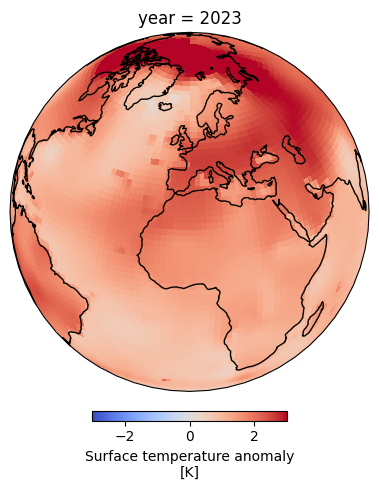

In [26]:
projection = ccrs.Orthographic(0, 30)

fig, ax = plt.subplots(1, 1, subplot_kw={'projection': projection})
fig.set_size_inches(5,5)

cbar_kwargs = {
    'orientation':'horizontal',
    'fraction': 0.025,
    'pad': 0.05,
    'extend':'neither'
}

anomaly.plot.imshow(ax=ax,
    vmin=-3, vmax=3, cmap='coolwarm',
    transform=ccrs.PlateCarree(),
    cbar_kwargs=cbar_kwargs)

ax.coastlines()
plt.tight_layout()
plt.show()